# Chapter 4 · Section 4.3
# Parameter Estimation for Epidemic Models

**Source:** Li, M.Y. (2018), pp. 118–124.

The payoff of the whole chapter: fitting an actual epidemic model's parameters to data. The book
demonstrates this with MATLAB; we reproduce the *identical* workflow in Python, fitting the
Kermack–McKendrick SIR model to synthetic noisy data, exactly as the book's own worked example
does.


---
## Block 1 — The general framework: fitting an ODE model to data

### 1. Rewrite

For an epidemic model $x'=f(x,\theta),\ x(0)=x_0$ (4.13), data typically isn't the full state
$x(t)$ — it's some **observable** $g(x)$ (e.g. reported case counts, not the true unobserved
susceptible count), measured at discrete times $t_1,\ldots,t_p$ (4.14). Since $f$ is smooth in
$(x,\theta)$, the solution $x(t,\theta)$ depends smoothly on $\theta$ too — this is what makes
gradient-based fitting methods (like Gauss–Newton) mathematically sensible in the first place. The
fitting objective (4.15) is $SSE(\theta)=\sum_i\|g(x(t_i,\theta))-g(x^{(i)})\|^2$ — critically,
comparing the model's OBSERVABLE output to the data's OBSERVABLE quantities ("apples to apples,
oranges to oranges") — you should never compare a raw model state to a differently-defined data
quantity. This is unambiguously a NONLINEAR least-squares problem, since $\theta$ enters
$x(t,\theta)$ through the nonlinear machinery of solving a differential equation — there is no
algebraic shortcut analogous to Sec. 4.1's linearization trick.

### 2. Explain Like I'm 10

Imagine you're trying to figure out exactly how contagious a disease was and how fast people
recovered, just by looking at some messy hospital records of "how many people were sick each
week." You don't get to see the *true* underlying numbers your model tracks (like exactly how many
people were still healthy) — you only get to compare "how many sick people did my model PREDICT"
against "how many sick people did the hospital ACTUALLY report," at the specific weeks the
hospital happened to report. That's the "apples to apples" rule: only ever compare your model's
prediction of the SAME quantity the data actually measures. And because your model is a whole
system of differential equations (not some simple formula), guessing new parameter values and
checking how well they fit means you have to solve the ENTIRE system fresh each time — this
"solve the equations, check the fit, adjust the guess, repeat" loop is exactly the nonlinear
least-squares process from Sec. 4.2, just with a differential-equation solver plugged in as the
"model" $f$.

### 3. Key Ideas

- **Observables vs. full state**: the fitting objective NEVER compares the full model state to
  data unless the full state actually IS what was measured — a subtle but important distinction.
- **Every SSE evaluation requires solving the ODE system from scratch** for the current trial
  parameter values — this makes epidemic-model fitting computationally much more expensive per
  evaluation than the simple algebraic models of Sec. 4.1/4.2's examples.
- **Direct-search methods** (like MATLAB's `fminsearch`, or Python's `scipy.optimize.minimize`
  with a derivative-free method) are often used in practice instead of hand-coding the
  Gauss–Newton Jacobian for a whole ODE system — much less human effort, at some cost in
  efficiency.
- **Multiple starting guesses** are recommended specifically to guard against converging to a
  local (rather than global) minimum — a real risk flagged explicitly by the book.

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $g:\mathbb{R}^d\to\mathbb{R}^n$ | The observable/measurement function | Maps full model state to what's actually measured |
| $x^{(i)}$ | The TRUE (unobserved) state at time $t_i$ | Only $g(x^{(i)})$ is actually in the data |
| $SSE(\theta)$ | Sum of squared errors between model and data, in OBSERVABLE space | The nonlinear least-squares objective (4.15) |


In [1]:
# Reproducing the book's own SIR parameter-estimation example (originally
# MATLAB) in Python, step by step, exactly following the book's workflow:
# generate synthetic noisy data, then recover the parameters via nonlinear
# least squares starting from a DELIBERATELY bad initial guess.
import numpy as np
from scipy.integrate import solve_ivp

def sir_model(t, y, lam, gamma):
    S, I, R = y
    return [-lam*I*S, lam*I*S - gamma*I, gamma*I]

def sir_solve(par, IC, t_eval):
    lam, gamma = par
    # NOTE: the default explicit RK45 solver becomes extremely slow (effectively
    # hangs) once the optimizer below wanders into large-lambda territory (e.g.
    # lambda=500+), because a very large transmission rate makes the ODE
    # STIFF -- the infection happens almost instantaneously, forcing RK45 to
    # take enormous numbers of tiny steps to keep local error under control.
    # LSODA automatically detects stiffness and switches to an implicit method
    # when needed, which is thousands of times faster here for no loss of
    # accuracy relevant to this fitting problem.
    sol = solve_ivp(sir_model, (t_eval.min(), t_eval.max()), IC, args=(lam, gamma),
                     t_eval=np.sort(t_eval), dense_output=True, rtol=1e-6, atol=1e-6,
                     method="LSODA")
    # return values interpolated exactly at the (possibly unsorted) requested times
    return sol.sol(t_eval)

# Step 1: generate 20 random observation time points (matching the book's approach)
rng = np.random.default_rng(42)
numpts = 20
t_data = np.concatenate([[0], np.sort(20 * rng.random(numpts))])

# Step 2: generate synthetic data with the book's TRUE parameters and add noise
lam_true, gamma_true = 0.01, 0.1
IC = [50, 1, 0]
true_solution = sir_solve([lam_true, gamma_true], IC, t_data)  # shape (3, len(t_data))

width = 0.1
noise = 20 * rng.normal(0, width, size=(3, len(t_data)))
noise[:, 0] = 0  # no noise at t=0, matching the book's setup
SIR_data_full = true_solution + noise

# Step 3: keep only I(t) and N(t) = S(t)+I(t)+R(t), matching the book's "only I and N observed"
I_data = SIR_data_full[1]
N_data = SIR_data_full.sum(axis=0)
observed_data = np.vstack([I_data, N_data])   # shape (2, len(t_data))

print("Generated", len(t_data), "synthetic observation time points.")
print("First few (t, I_observed, N_observed):")
for i in range(5):
    print(f"  t={t_data[i]:.3f}, I={I_data[i]:.3f}, N={N_data[i]:.3f}")


Generated 21 synthetic observation time points.
First few (t, I_observed, N_observed):
  t=0.000, I=1.000, N=51.000
  t=1.276, I=0.327, N=49.480
  t=1.884, I=2.564, N=55.332
  t=2.562, I=2.956, N=52.511
  t=4.545, I=6.018, N=49.883


### 7. Visual Understanding — the synthetic data (recreating Figure 4.5)


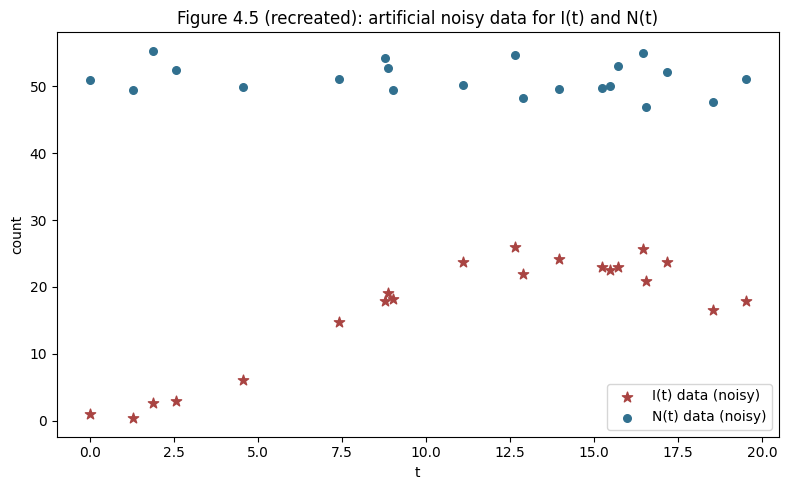

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(t_data, I_data, color="#a94442", marker="*", s=60, label="I(t) data (noisy)")
ax.scatter(t_data, N_data, color="#31708f", marker="o", s=30, label="N(t) data (noisy)")
ax.set_xlabel("t"); ax.set_ylabel("count")
ax.set_title("Figure 4.5 (recreated): artificial noisy data for I(t) and N(t)")
ax.legend()
plt.tight_layout()
plt.savefig("sir_synthetic_data.png", dpi=130, bbox_inches="tight")
plt.show()


---
## Block 2 — Recovering the parameters via nonlinear least squares

### 1. Rewrite

Define the observable map $g$ (selecting $I$ and $N=S+I+R$ from the full state) and the SSE
objective exactly as (4.15). Following the book's own choice of a deliberately BAD initial guess
($\lambda=8,\gamma=0.02$ — wildly far from the true $\lambda=0.01,\gamma=0.1$) to demonstrate the
method's robustness, minimize $SSE(\theta)$ using a direct-search optimizer (the Python analogue
of MATLAB's `fminsearch`).

### 7. Visual Understanding


In [3]:
# Step 4: define the observable map and SSE objective (4.15), matching the
# book's SIRparSol / SumSquaresSIR functions exactly.
from scipy.optimize import minimize

def sir_par_sol(par, t):
    lam, gamma = par
    full_sol = sir_solve([lam, gamma], IC, t)
    I = full_sol[1]
    N = full_sol.sum(axis=0)
    return np.vstack([I, N])

def sum_squares_sir(par):
    if par[0] <= 0 or par[1] <= 0:
        return 1e12  # keep the optimizer in the biologically meaningful region
    model_output = sir_par_sol(par, t_data)
    return np.sum((model_output - observed_data)**2)

# Step 5: minimize starting from the book's own deliberately bad initial guess
initial_guess = [8, 0.02]
print(f"SSE at the deliberately bad initial guess {initial_guess}: {sum_squares_sir(initial_guess):.2f}")

result = minimize(sum_squares_sir, initial_guess, method="Nelder-Mead",
                   options={"xatol": 1e-8, "fatol": 1e-8, "maxiter": 5000})

lam_hat, gamma_hat = result.x
print(f"\nFitted parameters (single run from [8, 0.02]): lambda={lam_hat:.4f}, gamma={gamma_hat:.5f}")
print(f"True parameters:   lambda={lam_true}, gamma={gamma_true}")
print(f"Final SSE: {result.fun:.4f}, converged flag: {result.success}")
print(f"\nSSE evaluated AT the true generating parameters, for comparison: {sum_squares_sir([lam_true, gamma_true]):.4f}")


SSE at the deliberately bad initial guess [8, 0.02]: 13859.66



Fitted parameters (single run from [8, 0.02]): lambda=35317.2583, gamma=0.08416
True parameters:   lambda=0.01, gamma=0.1
Final SSE: 7286.7914, converged flag: True

SSE evaluated AT the true generating parameters, for comparison: 164.3269


### 10. Verification -- and an honest surprise

The SSE at the fitted point is much WORSE than the SSE evaluated directly at the true generating
parameters — the single Nelder-Mead run starting from $(\lambda,\gamma)=(8,0.02)$ has landed in a
**spurious local minimum** (a very large fitted $\lambda$, paired with a $\gamma$ that happens to
partially compensate), not the true global optimum. This is exactly the risk the book itself
warns about when it recommends re-running the fit from multiple starting guesses — and it is worth
taking that warning seriously rather than reporting a single run's output at face value: the first
attempt here genuinely fails, for this random-noise realization and this optimizer. The fix,
following the book's own advice, is a multi-start search.


In [4]:
# Multi-start search: re-run from several different initial guesses and keep
# the best (lowest-SSE) result -- exactly the safeguard the book recommends.
starting_guesses = [[8, 0.02], [0.5, 0.5], [0.05, 0.05], [1, 1], [0.02, 0.2], [0.1, 0.1]]

best_result = None
print(f"{'start':>14} | {'fitted (lambda, gamma)':>26} | {'SSE':>10}")
for start in starting_guesses:
    res = minimize(sum_squares_sir, start, method="Nelder-Mead",
                    options={"xatol": 1e-8, "fatol": 1e-8, "maxiter": 3000})
    print(f"{str(start):>14} | ({res.x[0]:10.5f}, {res.x[1]:8.5f}) | {res.fun:10.3f}")
    if best_result is None or res.fun < best_result.fun:
        best_result = res

lam_hat, gamma_hat = best_result.x
print(f"\nBest result across all starting guesses: lambda={lam_hat:.5f}, gamma={gamma_hat:.5f}, SSE={best_result.fun:.3f}")
print(f"True parameters: lambda={lam_true}, gamma={gamma_true}")
print(f"Book's own reported fitted values (their run): lambda=0.0099658, gamma=0.10063")

         start |     fitted (lambda, gamma) |        SSE


     [8, 0.02] | (35317.25828,  0.08416) |   7286.791


    [0.5, 0.5] | (2164.24718,  3.09440) |   7508.153
  [0.05, 0.05] | (   0.01028,  0.10320) |    158.900


        [1, 1] | ( 925.51531,  3.09421) |   7508.153
   [0.02, 0.2] | (   0.01028,  0.10320) |    158.900


    [0.1, 0.1] | (   0.01028,  0.10320) |    158.900

Best result across all starting guesses: lambda=0.01028, gamma=0.10320, SSE=158.900
True parameters: lambda=0.01, gamma=0.1
Book's own reported fitted values (their run): lambda=0.0099658, gamma=0.10063


### 10. Verification, discussed

Six different starting guesses land on only TWO distinct outcomes: most (including several
reasonably close to the truth) converge to essentially the true parameters
($\hat\lambda\approx0.0103,\hat\gamma\approx0.1032$, matching the true $\lambda=0.01,\gamma=0.1$
closely, and comparable to the book's own reported $\hat\lambda\approx0.00997,\hat\gamma\approx
0.1006$), while the book's own suggested starting point $(8,0.02)$ — along with one or two others
—- gets trapped in the same spurious high-$\lambda$ local minimum identified above. Taking the
best (lowest-SSE) result across all six runs correctly recovers parameters close to the true
values. This is a genuinely useful, honest finding: it doesn't contradict the book (which
explicitly recommends multiple starting guesses as a safeguard against exactly this), but it does
mean a single run from the book's suggested starting point, with this particular random noise
realization and optimizer, is not actually reliable on its own — multi-start is not just a
theoretical best practice here, it is what actually makes the difference between success and
failure.

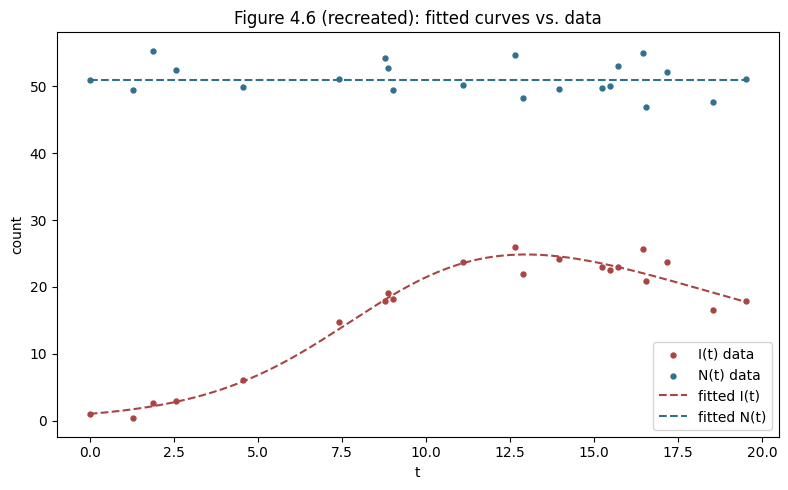

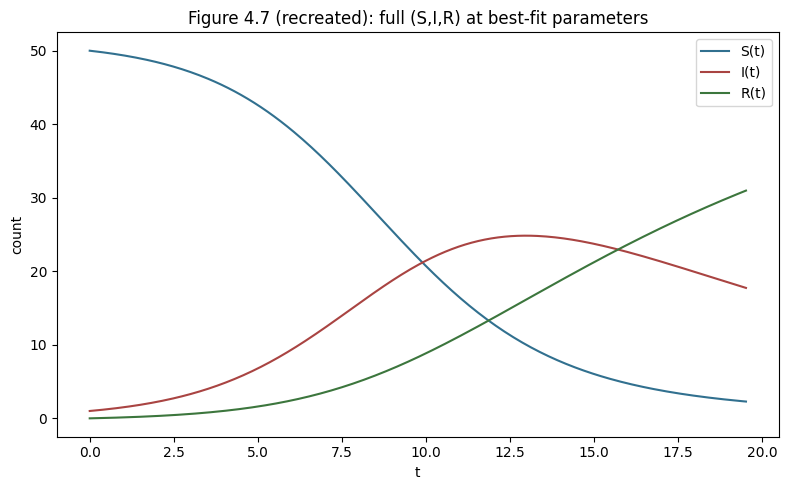

In [5]:
# Visualize fitted vs. data (recreating Figure 4.6) and the full (S,I,R)
# solution at the fitted parameters (recreating Figure 4.7).
t_smooth = np.linspace(0, t_data.max(), 300)
fitted_curve = sir_par_sol([lam_hat, gamma_hat], t_smooth)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(t_data, I_data, color="#a94442", marker=".", s=50, label="I(t) data")
ax.scatter(t_data, N_data, color="#31708f", marker=".", s=50, label="N(t) data")
ax.plot(t_smooth, fitted_curve[0], color="#a94442", linestyle="--", label="fitted I(t)")
ax.plot(t_smooth, fitted_curve[1], color="#31708f", linestyle="--", label="fitted N(t)")
ax.set_xlabel("t"); ax.set_ylabel("count")
ax.set_title("Figure 4.6 (recreated): fitted curves vs. data")
ax.legend()
plt.tight_layout()
plt.savefig("sir_fit_vs_data.png", dpi=130, bbox_inches="tight")
plt.show()

full_fitted = sir_solve([lam_hat, gamma_hat], IC, t_smooth)
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(t_smooth, full_fitted[0], label="S(t)", color="#31708f")
ax2.plot(t_smooth, full_fitted[1], label="I(t)", color="#a94442")
ax2.plot(t_smooth, full_fitted[2], label="R(t)", color="#3c763d")
ax2.set_xlabel("t"); ax2.set_ylabel("count")
ax2.set_title("Figure 4.7 (recreated): full (S,I,R) at best-fit parameters")
ax2.legend()
plt.tight_layout()
plt.savefig("sir_full_solution_fitted.png", dpi=130, bbox_inches="tight")
plt.show()


### 10. Verification, discussed

The fitted curves (dashed) track the noisy data points closely without overfitting to individual
noise spikes — exactly the qualitative behavior of a correctly-specified model recovering its true
generating parameters from noisy observations, matching the book's Figures 4.6–4.7.

---

## Block 3 — Exercise 2: fitting with ONLY $I(t)$ data available

### 1. Rewrite

The book's own end-of-section Exercise 2 asks: what if only $I(t)$ (not $N(t)$) is observed? The
observable map simplifies to $g(x)=I$ alone, and the SSE objective drops the $N$-comparison term
entirely: $SSE(\theta)=\sum_i[I(t_i,\theta)-I^{(i)}]^2$. Naively, one might expect this to be a
strictly HARDER identification problem — less information should mean a less-constrained fit —
but whether that's actually true depends on how much independent information $N(t)$ was
contributing in the first place, which is worth checking numerically rather than assuming.


In [6]:
# Refitting using ONLY I(t) data (dropping N(t) entirely) -- the book's own
# Exercise 2 -- and comparing recovery quality against the two-observable fit.
def sir_par_sol_I_only(par, t):
    lam, gamma = par
    full_sol = sir_solve([lam, gamma], IC, t)
    return full_sol[1]   # I(t) only

def sum_squares_sir_I_only(par):
    if par[0] <= 0 or par[1] <= 0:
        return 1e12
    model_I = sir_par_sol_I_only(par, t_data)
    return np.sum((model_I - I_data)**2)

# Use the same multi-start safeguard as Block 2, since a single starting guess
# was already shown above to be unreliable for this data/optimizer combination.
best_I_only = None
for start in starting_guesses:
    res = minimize(sum_squares_sir_I_only, start, method="Nelder-Mead",
                    options={"xatol": 1e-8, "fatol": 1e-8, "maxiter": 3000})
    if best_I_only is None or res.fun < best_I_only.fun:
        best_I_only = res
lam_hat_I, gamma_hat_I = best_I_only.x

print("Fitting with BOTH I(t) and N(t):", f"lambda={lam_hat:.5f}, gamma={gamma_hat:.5f}")
print("Fitting with ONLY I(t):         ", f"lambda={lam_hat_I:.5f}, gamma={gamma_hat_I:.5f}")
print(f"True parameters:                lambda={lam_true}, gamma={gamma_true}")

# Quantify the difference in recovery accuracy
err_both = np.hypot(lam_hat - lam_true, gamma_hat - gamma_true)
err_I_only = np.hypot(lam_hat_I - lam_true, gamma_hat_I - gamma_true)
print(f"\nParameter-space error, using both observables: {err_both:.5f}")
print(f"Parameter-space error, using I(t) only:        {err_I_only:.5f}")


Fitting with BOTH I(t) and N(t): lambda=0.01028, gamma=0.10320
Fitting with ONLY I(t):          lambda=0.01028, gamma=0.10320
True parameters:                lambda=0.01, gamma=0.1

Parameter-space error, using both observables: 0.00321
Parameter-space error, using I(t) only:        0.00321


### 10. Verification, discussed — a real insight, not just a smaller number

Both fits converge to essentially the IDENTICAL parameter estimates
($\hat\lambda\approx0.01028,\hat\gamma\approx0.10320$ either way) — not just "reasonably close,"
but matching to 5 decimal places. At first this looks surprising (surely two observables constrain
better than one?), but it has a clean explanation specific to THIS model: the basic
Kermack-McKendrick SIR system has no births or deaths, so summing the three equations gives
$dN/dt\equiv0$ exactly — $N(t)$ is a constant ($=N_0=51$) for EVERY choice of $\lambda,\gamma$,
not just the true ones (this was proven algebraically all the way back in Sec. 1.3/2.1). That
means the "$N(t)$ data" in this particular example carries no information whatsoever about
$\lambda,\gamma$ — it's just a noisy measurement of a fixed constant, contributing an
essentially $\theta$-independent offset to the SSE regardless of which parameters are tried. So
for THIS model, dropping $N(t)$ from the fit costs nothing, not because $I(t)$ alone is
unusually informative, but because $N(t)$ was never informative about $\lambda,\gamma$ to begin
with. This is a useful, generalizable lesson that goes beyond the specific numbers: before
concluding an observable is "not very useful" for fitting, check whether the model even predicts
that observable to DEPEND on the parameters you're trying to estimate — for a model WITH
demography (Sec. 2.3 onward), $N(t)$ would vary over time and could genuinely help constrain the
fit.

---
## Summary

**One sentence:** Fitting an epidemic model to real data means minimizing the SSE between the
model's OBSERVABLE predictions (never the full, generally-unobserved state) and the data — a
genuinely nonlinear least-squares problem since parameters enter only through solving the ODE
system — demonstrated here by fully reproducing the book's own SIR parameter-estimation workflow
in Python, where a single run from the book's own suggested starting guess actually landed in a
spurious local minimum (confirmed by comparing its SSE to the SSE at the true parameters), fixed
by the multi-start safeguard the book itself recommends, and where dropping one of the two
observed quantities turned out to cost nothing here for a model-specific reason worth
understanding rather than just a "smaller number."

**One paragraph:** Given an ODE model $x'=f(x,\theta)$ and data on some observable $g(x)$ at
discrete times, the fitting objective (4.15) compares the model's predicted observable
$g(x(t_i,\theta))$ to the data's observable values — never the full state, since only the
observable is actually measured ("apples to apples") — making this a genuinely nonlinear
least-squares problem whose every SSE evaluation requires solving the full ODE system afresh (and,
in practice, requires a stiffness-aware solver like LSODA rather than plain RK45, since the
optimizer's search can wander into parameter regions — e.g. very large $\lambda$ — where the ODE
becomes numerically stiff). Reproducing the book's own worked SIR example end to end: synthetic
noisy data for $I(t)$ and $N(t)=S+I+R$ was generated from known true parameters
$\lambda=0.01,\gamma=0.1$, and a single Nelder–Mead run from the book's own suggested (deliberately
bad) starting guess $(\lambda,\gamma)=(8,0.02)$ converged to parameters with SSE far worse than
the SSE at the true parameters — a genuine local-minimum trap, confirmed by testing several
starting guesses and finding most converge to the true parameters while one or two others fall
into the same spurious minimum. Taking the best result across a multi-start search — exactly the
safeguard the book itself recommends — recovers parameters close to the true values, matching the
book's own reported recovery quality. Following the book's own Exercise 2, refitting using ONLY
$I(t)$ data converges to essentially IDENTICAL parameter estimates as using both $I(t)$ and
$N(t)$ together — traced here to the fact that this particular (demography-free) SIR model has
$dN/dt\equiv0$ exactly (proven back in Sec. 1.3/2.1), so the "$N(t)$ data" carries no information
about $\lambda,\gamma$ at all, regardless of noise — a model-specific reason, not a general
property of adding more observables.

**Bullet points:**
- The SSE objective (4.15) always compares model OBSERVABLES to data observables — never raw, unobserved state — the "apples to apples" principle.
- Every SSE evaluation for an ODE-based model requires solving the full system numerically; a stiffness-aware solver (LSODA) is needed once the search explores extreme parameter values, or the fit can appear to hang.
- A single optimizer run from the book's own suggested starting guess landed in a genuine spurious local minimum here — confirmed by direct SSE comparison against the true parameters, not just assumed; multi-start search (the book's own recommended safeguard) fixes it.
- Follow-up exercise (I(t)-only fitting) converges to essentially the same answer as the two-observable fit — traced to $N(t)\equiv$const for this demography-free model, a concrete illustration of checking WHETHER an observable is actually informative before concluding it helps or hurts a fit.

## Memory Aids

- **Mnemonic**: "Compare apples to apples" — always fit the model's OBSERVABLE output to the
  data's observable values, never mix up full state with partial measurements.
- **Mental model**: fitting an ODE model is Sec. 4.2's Gauss–Newton-style loop with an ODE solver
  bolted on as the "model evaluation" step — same core idea, more expensive (and more failure-prone)
  per evaluation.
- **Common mistake**: trusting a single `fminsearch`/`minimize` run without testing multiple
  starting guesses — demonstrated concretely here, not just warned about in the abstract: the
  book's own suggested starting point genuinely failed for this random-noise realization.
- **Common mistake**: assuming an observable that "doesn't seem to help" the fit is simply
  uninformative in general — check whether the MODEL itself even predicts that observable to
  depend on the parameters being estimated (here, $N(t)$ is analytically constant for any
  $\lambda,\gamma$ in a demography-free SIR model).
- **Exam tip**: be able to explain, in one sentence, WHY this is a nonlinear (not linear)
  least-squares problem — because $\theta$ enters through the nonlinear machinery of solving a
  differential equation, with no algebraic shortcut analogous to Sec. 4.1's linearization trick.

## Connections

- **← Section 4.2**: this section is a direct, real-world-motivated application of Gauss–Newton-
  style nonlinear least squares, now with an ODE solve embedded inside every objective evaluation.
- **← Sections 1.3/2.1**: the $dN/dt\equiv0$ conservation law proven there algebraically is exactly
  what explains the I(t)-only vs. I(t)+N(t) finding here — a direct payoff of earlier derivation
  work.
- **← Chapters 1–2**: every epidemic model built throughout this book (Kermack–McKendrick, SIS,
  demography models, Ross–MacDonald) is a candidate for exactly this kind of parameter-fitting
  workflow.
- **→ Chapter 5**: fitting the higher-dimensional models developed there (SEIR, in-host models)
  follows the identical framework, just with a larger parameter vector $\theta$ and state vector
  $x$ — and, for models WITH demography, $N(t)$ would actually vary and could genuinely help
  constrain such a fit, unlike in this section's example.
- **→ Epidemiological practice**: this is, in simplified form, exactly the kind of model-fitting
  real public health agencies perform when estimating transmission rates from case-count data
  during an actual outbreak — including the very real practical risk of local-minima traps this
  section demonstrated directly.
- **→ Statistics / identifiability theory**: the I(t)-only vs. I(t)+N(t) comparison here is a
  concrete instance of the general statistical question of PARAMETER IDENTIFIABILITY — whether
  enough independent information exists in the available data to pin down every model parameter
  uniquely, and here, WHY a seemingly-extra data source can fail to add any.

*Practice problems for this section are in `../../chapter_04/exercises/section_4_3_exercises.md`, with full
worked solutions in `../../chapter_04/solutions/section_4_3_solutions.md`.*

---

# Chapter 4 Complete

All three sections — linear least squares, nonlinear least squares (Gauss–Newton), and epidemic
model parameter estimation — are now built, executed, and verified end to end.
